In [ ]:
import pandas as pd

# STEP 1: Load dataset
df = pd.read_excel('/KPK data set.xlsx')

# Basic sanity checks
print("Shape of dataset:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

# Preview data
df.head()



Shape of dataset: (501, 41)

Column names:
['GN', 'AG', 'MS', 'RS', 'ES', 'FI', 'ED', 'CI', 'F1', 'F2', 'F3', 'F4', 'F5', 'F6', 'F7', 'P1', 'P2', 'P3', 'P4', 'P5', 'P6', 'P7', 'A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'M1', 'M2', 'M3', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7']


,GN,AG,MS,RS,ES,FI,ED,CI,F1,F2,...,M1,M2,M3,D1,D2,D3,D4,D5,D6,D7
0,0,1,0,0,0,3,3,1,1,1,...,4,2,1.0,1,1,1,1,1,1,1
1,1,2,0,1,1,3,2,0,2,2,...,4,4,2.0,1,1,2,2,2,2,1
2,0,3,1,1,1,3,4,0,3,4,...,4,4,3.0,1,1,1,1,1,1,1
3,0,2,1,1,1,3,2,1,2,4,...,2,4,2.0,1,1,1,1,1,1,1
4,0,2,1,1,1,3,2,1,2,3,...,1,4,1.0,1,1,1,1,1,1,1


In [ ]:
# STEP 2A: Define question columns
anxiety_cols = ['A1','A2','A3','A4','A5','A6','A7','A8','A9']
depression_cols = ['D1','D2','D3','D4','D5','D6','D7']

# Compute total scores
df['Anxiety_Score'] = df[anxiety_cols].sum(axis=1)
df['Depression_Score'] = df[depression_cols].sum(axis=1)

# Quick sanity check
df[['Anxiety_Score', 'Depression_Score']].describe()


,Anxiety_Score,Depression_Score
count,501.000000,501.000000
mean,34.982036,10.333333
std,4.663226,4.618080
min,17.000000,7.000000
25%,32.000000,7.000000
50%,35.000000,8.000000
75%,37.000000,12.000000
max,45.000000,28.000000


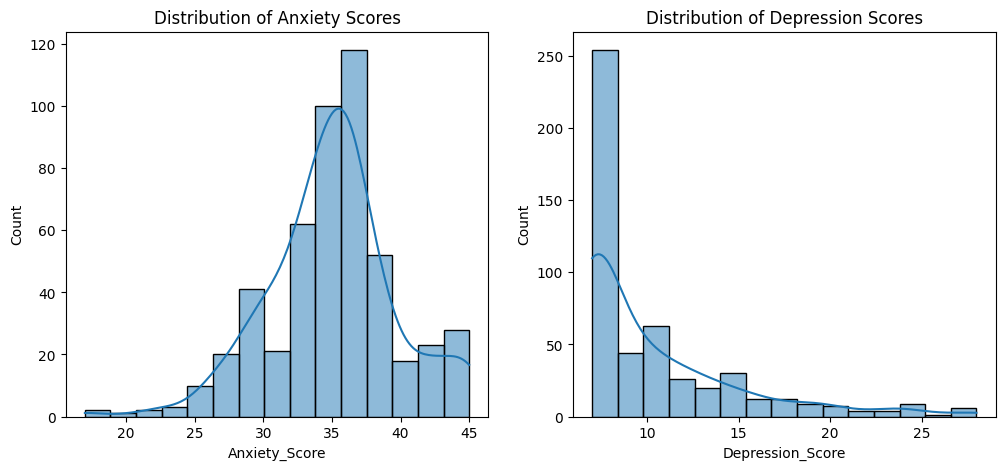

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(df['Anxiety_Score'], bins=15, kde=True)
plt.title("Distribution of Anxiety Scores")

plt.subplot(1,2,2)
sns.histplot(df['Depression_Score'], bins=15, kde=True)
plt.title("Distribution of Depression Scores")

plt.show()


In [ ]:
# STEP 2C: Create data-driven risk labels using 75th percentile

anxiety_threshold = df['Anxiety_Score'].quantile(0.75)
depression_threshold = df['Depression_Score'].quantile(0.75)

df['Anxiety_Risk'] = (df['Anxiety_Score'] >= anxiety_threshold).astype(int)
df['Depression_Risk'] = (df['Depression_Score'] >= depression_threshold).astype(int)

# Check class balance
print("Anxiety Risk Distribution:")
print(df['Anxiety_Risk'].value_counts(), "\n")

print("Depression Risk Distribution:")
print(df['Depression_Risk'].value_counts())


Anxiety Risk Distribution:
Anxiety_Risk
0    343
1    158
Name: count, dtype: int64 

Depression Risk Distribution:
Depression_Risk
0    361
1    140
Name: count, dtype: int64


In [ ]:
# STEP 3A: Missing values
missing = df.isnull().sum()
missing[missing > 0]


,0
M3,2


In [ ]:
# STEP 3B: Duplicate rows
print("Duplicate rows:", df.duplicated().sum())


Duplicate rows: 18


In [ ]:
# STEP 3C: Data types
df.dtypes


,0
GN,int64
AG,int64
MS,int64
RS,int64
ES,int64
FI,int64
ED,int64
CI,int64
F1,int64
F2,int64


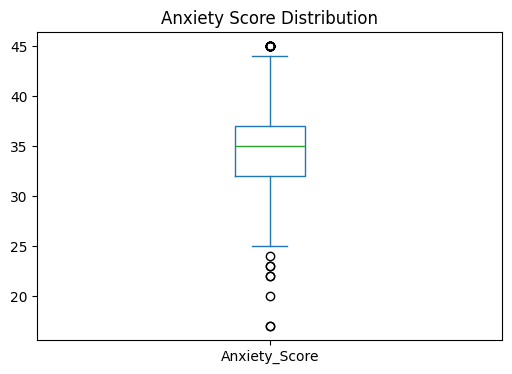

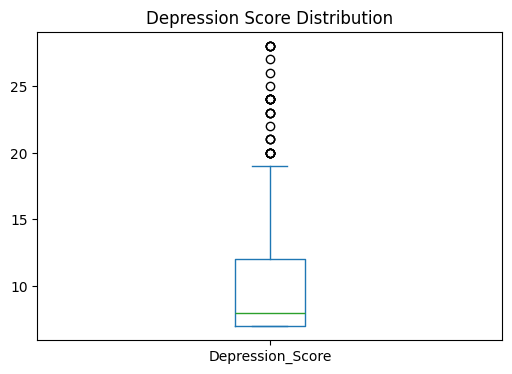

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
df['Anxiety_Score'].plot(kind='box')
plt.title('Anxiety Score Distribution')
plt.show()

plt.figure(figsize=(6,4))
df['Depression_Score'].plot(kind='box')
plt.title('Depression Score Distribution')
plt.show()


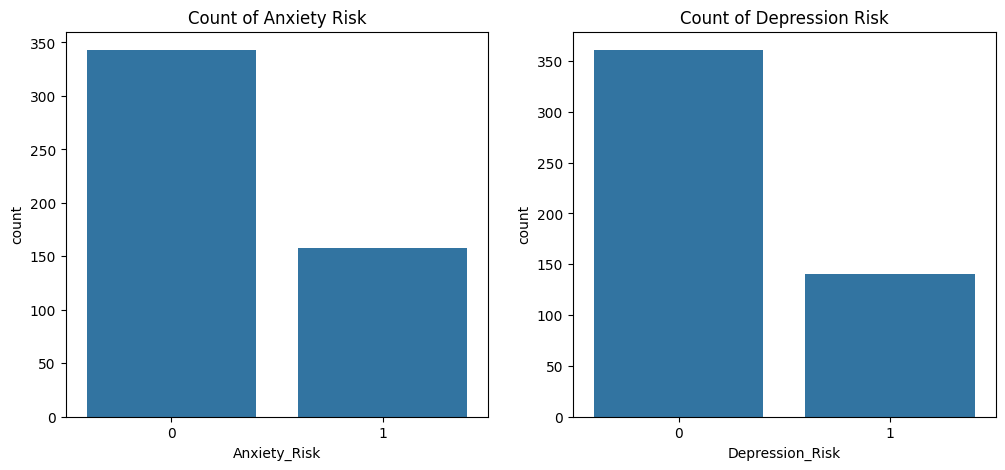

In [24]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.countplot(x='Anxiety_Risk', data=df)
plt.title("Count of Anxiety Risk")

plt.subplot(1,2,2)
sns.countplot(x='Depression_Risk', data=df)
plt.title("Count of Depression Risk")
plt.show()


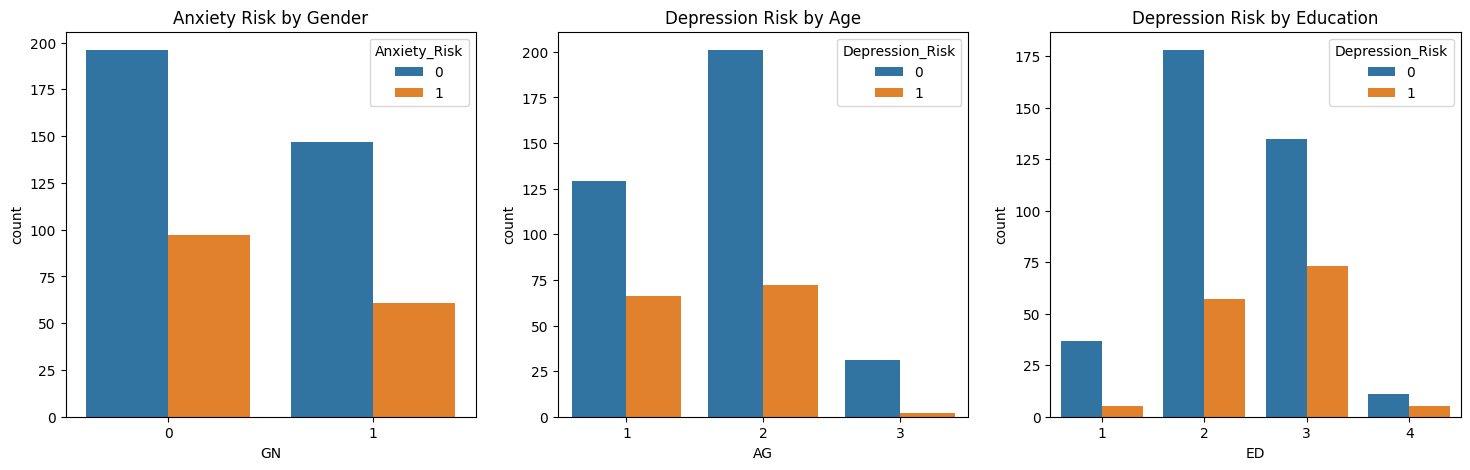

In [25]:
plt.figure(figsize=(18,5))
plt.subplot(1,3,1)
sns.countplot(x='GN', hue='Anxiety_Risk', data=df)
plt.title("Anxiety Risk by Gender")

plt.subplot(1,3,2)
sns.countplot(x='AG', hue='Depression_Risk', data=df)
plt.title("Depression Risk by Age")

plt.subplot(1,3,3)
sns.countplot(x='ED', hue='Depression_Risk', data=df)
plt.title("Depression Risk by Education")
plt.show()


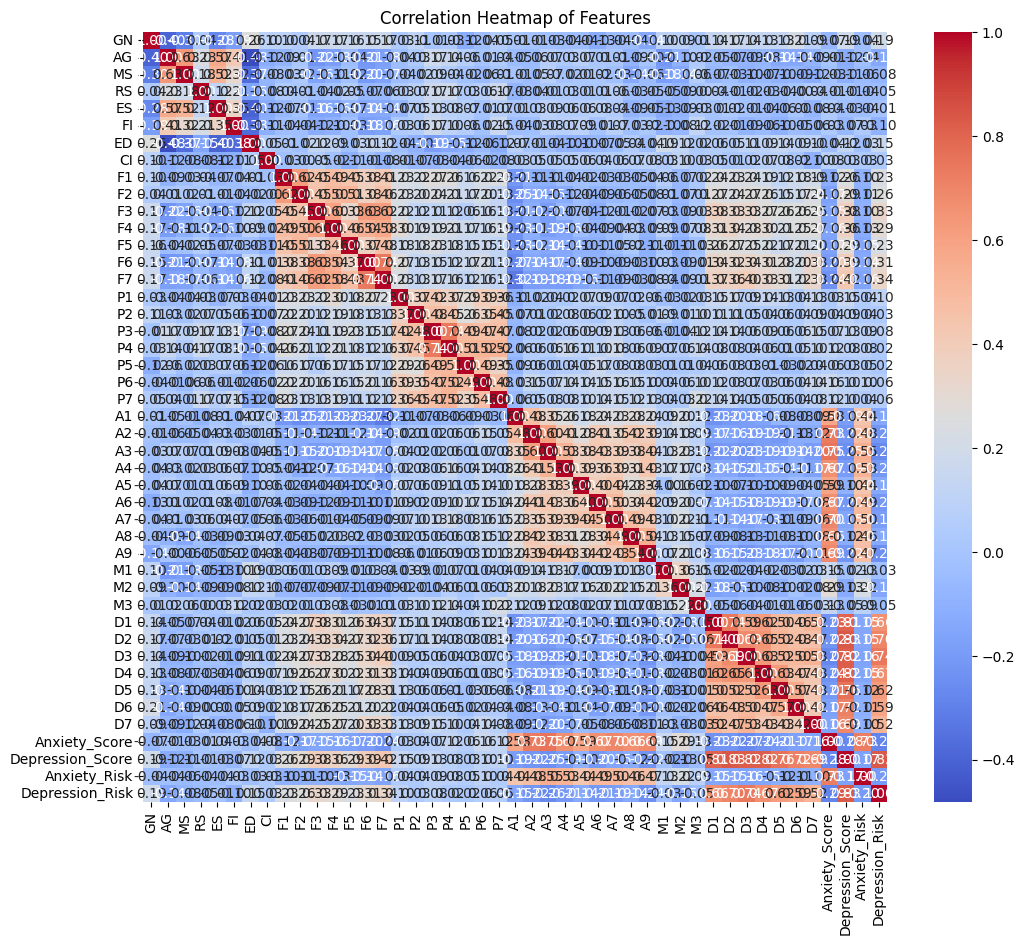

In [26]:
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Heatmap of Features")
plt.show()


In [41]:
from sklearn.model_selection import train_test_split

# Define feature columns and target
feature_cols = df.drop(columns=['Depression_Risk', 'Anxiety_Risk', 'Anxiety_Score', 'Depression_Score']).columns
X = df[feature_cols]
yD = df['Depression_Risk']

# Train-test split
X_trainD, X_testD, y_trainD, y_testD = train_test_split(X, yD, test_size=0.2, random_state=42, stratify=yD)


In [42]:
# Step 4: Model Training / Testing (Corrected)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pandas as pd

# 1. Define features and target
X = df.drop(['Anxiety_Risk', 'Depression_Risk', 'Anxiety_Score', 'Depression_Score'], axis=1)
y = df['Anxiety_Risk']

# 2. Handle missing values (fill with median)
X = X.fillna(X.median())

# 3. Convert all to numeric
X = X.apply(pd.to_numeric)

# 4. Split into train/test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# 5. Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 6. Train Logistic Regression model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# 7. Predictions
y_pred = model.predict(X_test)

# 8. Evaluation
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred)

print("Accuracy:", accuracy)
print("Confusion Matrix:\n", conf_matrix)
print("Classification Report:\n", report)


Accuracy: 0.9405940594059405
Confusion Matrix:
 [[63  0]
 [ 6 32]]
Classification Report:
               precision    recall  f1-score   support

           0       0.91      1.00      0.95        63
           1       1.00      0.84      0.91        38

    accuracy                           0.94       101
   macro avg       0.96      0.92      0.93       101
weighted avg       0.95      0.94      0.94       101



In [43]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Random Forest Baseline
rf_base = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'  # handles class imbalance
)

rf_base.fit(X_train, y_train)
y_pred_rf = rf_base.predict(X_test)

# Evaluation
accuracy_rf = accuracy_score(y_test, y_pred_rf)
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)
report_rf = classification_report(y_test, y_pred_rf)

print("Random Forest Baseline Accuracy:", accuracy_rf)
print("Confusion Matrix:\n", conf_matrix_rf)
print("Classification Report:\n", report_rf)


Random Forest Baseline Accuracy: 0.9108910891089109
Confusion Matrix:
 [[61  2]
 [ 7 31]]
Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.97      0.93        63
           1       0.94      0.82      0.87        38

    accuracy                           0.91       101
   macro avg       0.92      0.89      0.90       101
weighted avg       0.91      0.91      0.91       101



In [44]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Example for Anxiety_Risk
# Using Pipeline ensures scaling is applied inside cross-validation
log_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42
    ))
])

rf_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight='balanced'
    ))
])

# Fit models
log_pipe.fit(X_train, y_train)
rf_pipe.fit(X_train, y_train)

# Predict
pred_log = log_pipe.predict(X_test)
pred_rf = rf_pipe.predict(X_test)

# Evaluate Logistic Regression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Logistic Regression (Pipeline) Accuracy:", accuracy_score(y_test, pred_log))
print("Confusion Matrix:\n", confusion_matrix(y_test, pred_log))
print("Classification Report:\n", classification_report(y_test, pred_log))

# Evaluate Random Forest
print("Random Forest (Pipeline) Accuracy:", accuracy_score(y_test, pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, pred_rf))
print("Classification Report:\n", classification_report(y_test, pred_rf))


Logistic Regression (Pipeline) Accuracy: 0.9405940594059405
Confusion Matrix:
 [[62  1]
 [ 5 33]]
Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.98      0.95        63
           1       0.97      0.87      0.92        38

    accuracy                           0.94       101
   macro avg       0.95      0.93      0.94       101
weighted avg       0.94      0.94      0.94       101

Random Forest (Pipeline) Accuracy: 0.9108910891089109
Confusion Matrix:
 [[61  2]
 [ 7 31]]
Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.97      0.93        63
           1       0.94      0.82      0.87        38

    accuracy                           0.91       101
   macro avg       0.92      0.89      0.90       101
weighted avg       0.91      0.91      0.91       101



In [45]:
log_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42
    ))
])

log_pipe.fit(X_train, y_train)
pred_log = log_pipe.predict(X_test)

# Evaluate
print("Logistic Regression Baseline Accuracy:", accuracy_score(y_test, pred_log))
print("Confusion Matrix:\n", confusion_matrix(y_test, pred_log))
print("Classification Report:\n", classification_report(y_test, pred_log))


Logistic Regression Baseline Accuracy: 0.9405940594059405
Confusion Matrix:
 [[62  1]
 [ 5 33]]
Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.98      0.95        63
           1       0.97      0.87      0.92        38

    accuracy                           0.94       101
   macro avg       0.95      0.93      0.94       101
weighted avg       0.94      0.94      0.94       101



In [46]:
rf_base = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)

rf_base.fit(X_train, y_train)
pred_rf = rf_base.predict(X_test)

# Evaluate
print("Random Forest Baseline Accuracy:", accuracy_score(y_test, pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, pred_rf))
print("Classification Report:\n", classification_report(y_test, pred_rf))


Random Forest Baseline Accuracy: 0.8910891089108911
Confusion Matrix:
 [[60  3]
 [ 8 30]]
Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.95      0.92        63
           1       0.91      0.79      0.85        38

    accuracy                           0.89       101
   macro avg       0.90      0.87      0.88       101
weighted avg       0.89      0.89      0.89       101



In [47]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Base RF model
rf = RandomForestClassifier(
    random_state=42,
    class_weight='balanced'
)

# GridSearchCV
grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='f1',   # prioritize F1 for high-risk detection
    n_jobs=-1
)

# Fit on training data
grid_rf.fit(X_train, y_train)

# Best model
best_rf = grid_rf.best_estimator_
pred_best_rf = best_rf.predict(X_test)

# Evaluate
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Best RF Parameters:", grid_rf.best_params_)
print("Random Forest (Tuned) Accuracy:", accuracy_score(y_test, pred_best_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, pred_best_rf))
print("Classification Report:\n", classification_report(y_test, pred_best_rf))


Best RF Parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100}
Random Forest (Tuned) Accuracy: 0.9108910891089109
Confusion Matrix:
 [[60  3]
 [ 6 32]]
Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.95      0.93        63
           1       0.91      0.84      0.88        38

    accuracy                           0.91       101
   macro avg       0.91      0.90      0.90       101
weighted avg       0.91      0.91      0.91       101



In [48]:
# Define the feature columns from your dataframe
feature_cols = df.drop(columns=['Depression_Risk', 'Anxiety_Risk', 'Anxiety_Score', 'Depression_Score']).columns


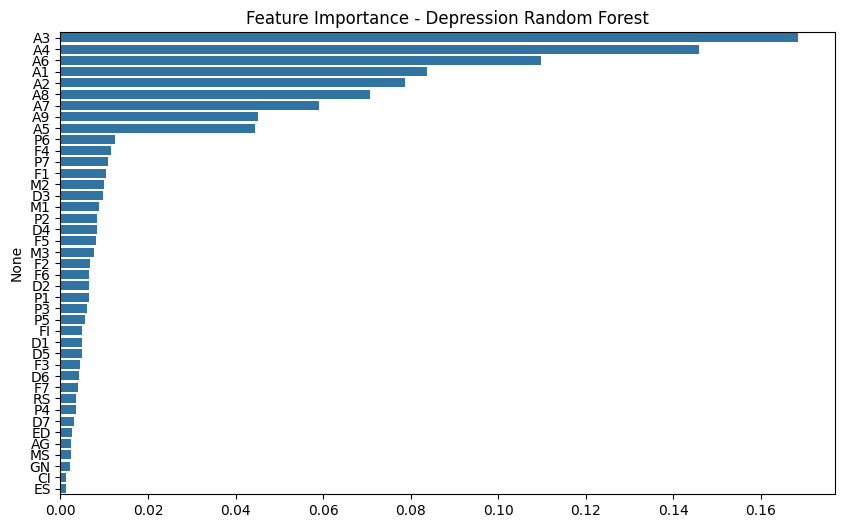

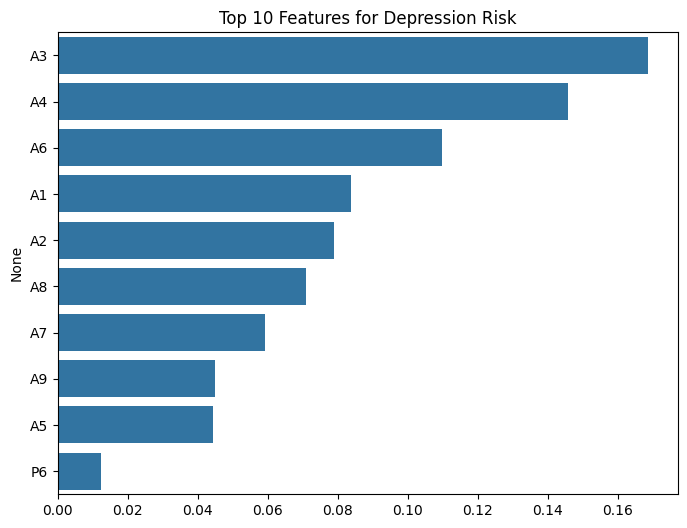

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define feature columns manually from your original dataframe
feature_cols = df.drop(columns=['Depression_Risk', 'Anxiety_Risk', 'Anxiety_Score', 'Depression_Score']).columns

# Create Series with feature importance from your already trained model
feat_importancesD = pd.Series(best_rf.feature_importances_, index=feature_cols).sort_values(ascending=False)

# Full importance barplot
plt.figure(figsize=(10,6))
sns.barplot(x=feat_importancesD.values, y=feat_importancesD.index)
plt.title("Feature Importance - Depression Random Forest")
plt.show()

# Top 10 features
top_features = feat_importancesD.head(10)
plt.figure(figsize=(8,6))
sns.barplot(x=top_features.values, y=top_features.index)
plt.title("Top 10 Features for Depression Risk")
plt.show()


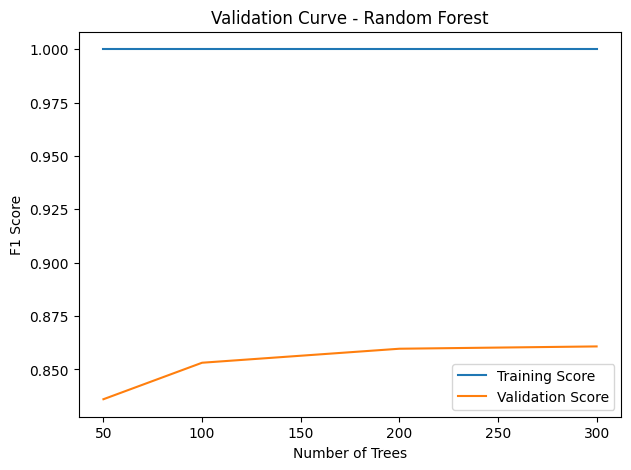

In [50]:
from sklearn.model_selection import validation_curve
import matplotlib.pyplot as plt
import numpy as np

param_range = [50, 100, 200, 300]

train_scores, val_scores = validation_curve(
    RandomForestClassifier(
        random_state=42,
        class_weight='balanced'
    ),
    X_train, y_train,
    param_name="n_estimators",
    param_range=param_range,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)

plt.figure(figsize=(7,5))
plt.plot(param_range, train_mean, label="Training Score")
plt.plot(param_range, val_mean, label="Validation Score")
plt.xlabel("Number of Trees")
plt.ylabel("F1 Score")
plt.title("Validation Curve - Random Forest")
plt.legend()
plt.show()


/tmp/ipython-input-998317580.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_importancesD.values, y=feat_importancesD.index, palette="viridis")


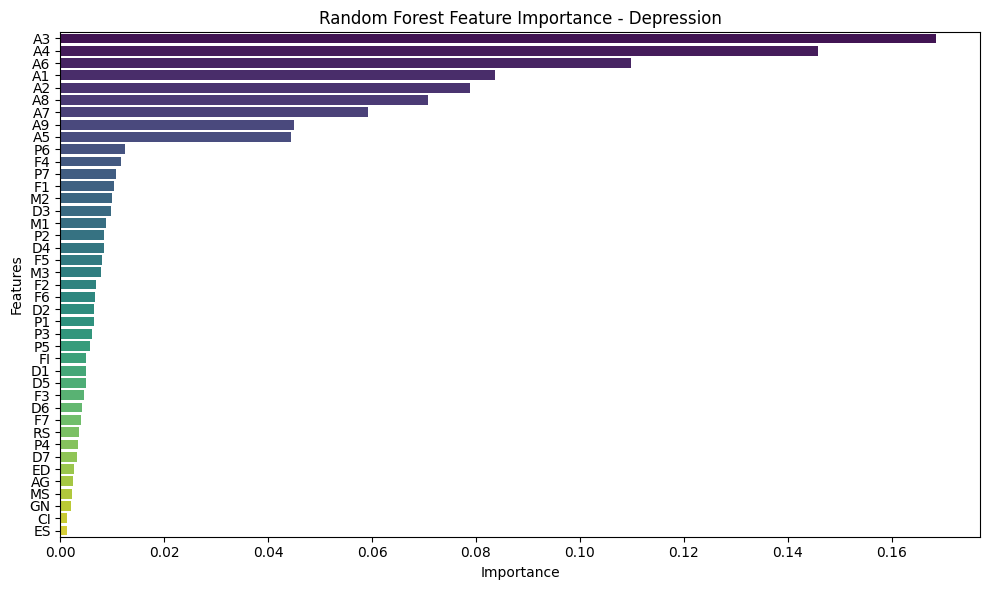

/tmp/ipython-input-998317580.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_features.values, y=top_features.index, palette="magma")


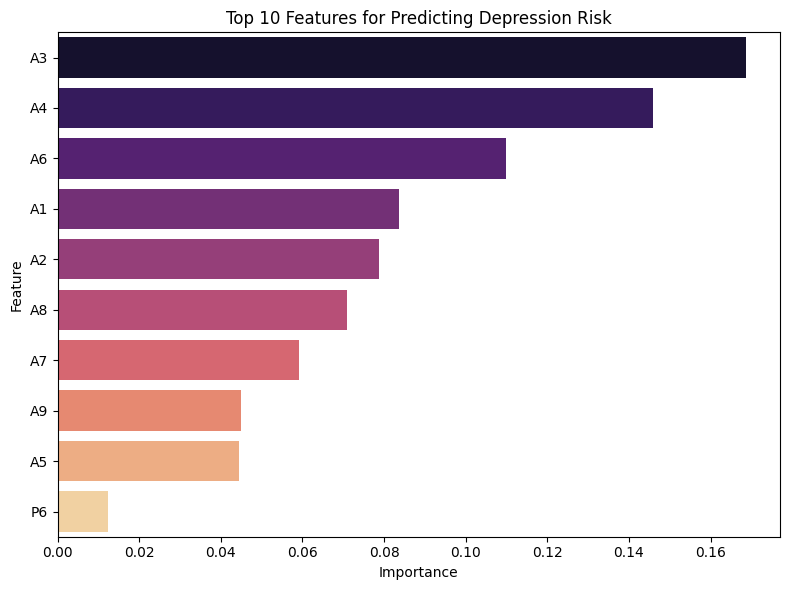

In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#  Define feature columns (from your dataset)
feature_cols = df.drop(columns=['Depression_Risk', 'Anxiety_Risk', 'Anxiety_Score', 'Depression_Score']).columns

#  Get feature importance from your already trained best_rf model
feat_importancesD = pd.Series(best_rf.feature_importances_, index=feature_cols).sort_values(ascending=False)

#  Full feature importance barplot
plt.figure(figsize=(10,6))
sns.barplot(x=feat_importancesD.values, y=feat_importancesD.index, palette="viridis")
plt.title("Random Forest Feature Importance - Depression")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

# Optional: Top 10 features
top_features = feat_importancesD.head(10)
plt.figure(figsize=(8,6))
sns.barplot(x=top_features.values, y=top_features.index, palette="magma")
plt.title("Top 10 Features for Predicting Depression Risk")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


In [51]:
from sklearn.model_selection import cross_val_score
import numpy as np

# Use the best tuned RF from Step 9
cv_scores = cross_val_score(
    best_rf,       # best_rf from Step 9
    X_train,
    y_train,
    cv=5,
    scoring='f1'
)

print("Cross-Validation F1 Scores:", cv_scores)
print("Mean F1 Score:", np.mean(cv_scores))
print("Standard Deviation:", np.std(cv_scores))


Cross-Validation F1 Scores: [0.85106383 0.95652174 0.77777778 0.91666667 0.95833333]
Mean F1 Score: 0.8920726693390894
Standard Deviation: 0.06912896650880654


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


=== Logistic Regression ===
Confusion Matrix:
 [[ 0 73]
 [ 0 28]]
Accuracy: 0.277
Precision: 0.277
Recall: 1.0
F1 Score: 0.434

=== Random Forest (Tuned) ===
Confusion Matrix:
 [[ 0 73]
 [ 0 28]]
Accuracy: 0.277
Precision: 0.277
Recall: 1.0
F1 Score: 0.434


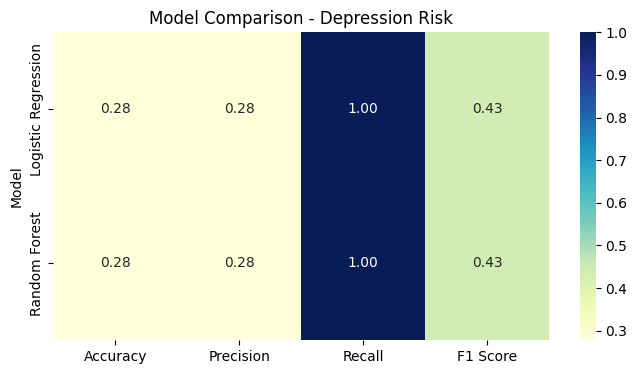

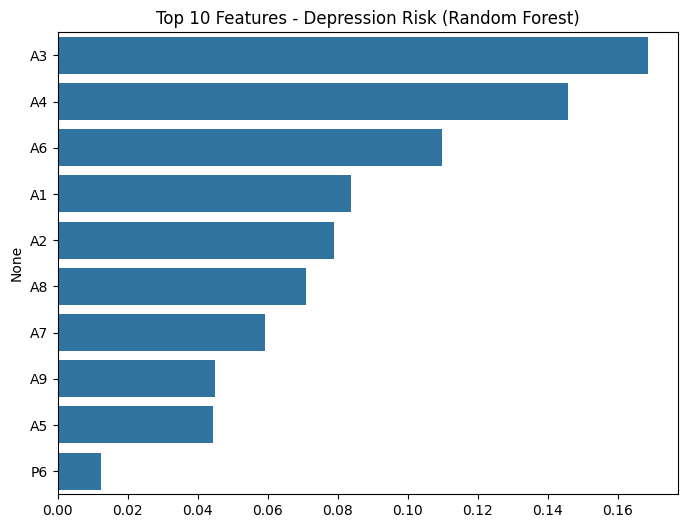

In [52]:

# STEP 12: Final Evaluation & Model Comparison
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure you have your test sets
# If not already split, define X_testD, y_testD etc.
# X_trainD, X_testD, y_trainD, y_testD = train_test_split(...)

#  Generate predictions for Depression
pred_logD = log_pipe.predict(X_testD)       # Logistic Regression
pred_best_rfD = best_rf.predict(X_testD)    # Random Forest (Tuned)

# Confusion Matrix & Classification Report (Optional)
cm_logD = confusion_matrix(y_testD, pred_logD)
cm_rfD = confusion_matrix(y_testD, pred_best_rfD)

print("=== Logistic Regression ===")
print("Confusion Matrix:\n", cm_logD)
print("Accuracy:", round(accuracy_score(y_testD, pred_logD), 3))
print("Precision:", round(precision_score(y_testD, pred_logD), 3))
print("Recall:", round(recall_score(y_testD, pred_logD), 3))
print("F1 Score:", round(f1_score(y_testD, pred_logD), 3))

print("\n=== Random Forest (Tuned) ===")
print("Confusion Matrix:\n", cm_rfD)
print("Accuracy:", round(accuracy_score(y_testD, pred_best_rfD), 3))
print("Precision:", round(precision_score(y_testD, pred_best_rfD), 3))
print("Recall:", round(recall_score(y_testD, pred_best_rfD), 3))
print("F1 Score:", round(f1_score(y_testD, pred_best_rfD), 3))

#  Model Comparison Heatmap
comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [accuracy_score(y_testD, pred_logD), accuracy_score(y_testD, pred_best_rfD)],
    'Precision': [precision_score(y_testD, pred_logD), precision_score(y_testD, pred_best_rfD)],
    'Recall': [recall_score(y_testD, pred_logD), recall_score(y_testD, pred_best_rfD)],
    'F1 Score': [f1_score(y_testD, pred_logD), f1_score(y_testD, pred_best_rfD)]
})

comparison_df.set_index('Model', inplace=True)

plt.figure(figsize=(8,4))
sns.heatmap(comparison_df, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Model Comparison - Depression Risk")
plt.show()

#Feature Importance (Top 10)
feature_cols = df.drop(columns=['Depression_Risk', 'Anxiety_Risk', 'Anxiety_Score', 'Depression_Score']).columns
feat_importancesD = pd.Series(best_rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
top_features = feat_importancesD.head(10)

plt.figure(figsize=(8,6))
sns.barplot(x=top_features.values, y=top_features.index)
plt.title("Top 10 Features - Depression Risk (Random Forest)")
plt.show()
